# Deep Neural Network — Genre Classification
**DS340 — Multiclass Genre Classification**

Three architectures compared:
- **NN-A**: 1 hidden layer (128)
- **NN-B**: 2 hidden layers (256 → 128)
- **NN-C**: 3 hidden layers (256 → 128 → 64)

All use: ReLU, Dropout (0.3), Cross-Entropy Loss, Adam optimizer, Early Stopping

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


---
## 1. Load & Preprocess Data

In [ ]:
data = pd.read_csv('../Data/spotify-tracks-dataset.csv')

drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'artists', 'album_name', 'track_name']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])
data = data.dropna()
data = data.drop_duplicates(subset='track_id', keep='first')
data = data.drop(columns=['track_id'])
print(f'Data shape (unique tracks only): {data.shape}')

In [3]:
le = LabelEncoder()
data['genre_label'] = le.fit_transform(data['track_genre'])
num_classes = len(le.classes_)

feature_cols = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

X = data[feature_cols].copy()
X['explicit'] = X['explicit'].astype(int)
y = data['genre_label'].values

del data
gc.collect()

print(f'Classes: {num_classes}, Features: {X.shape[1]}')

Classes: 114, Features: 15


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

del X, X_temp, y_temp
gc.collect()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# convert to tensors
X_train_t = torch.FloatTensor(X_train_sc).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val_sc).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test_sc).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True
)

print(f'Train: {X_train_sc.shape[0]:,}  Val: {X_val_sc.shape[0]:,}  Test: {X_test_sc.shape[0]:,}')

Train: 23,940  Val: 5,130  Test: 5,130


---
## 2. Define DNN Architecture

In [5]:
class GenreClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_model(name, hidden_dims, epochs=100, patience=10, lr=0.001):
    model = GenreClassifier(
        input_dim=X_train_sc.shape[1],
        num_classes=num_classes,
        hidden_dims=hidden_dims
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        # train
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        train_losses.append(epoch_loss / len(X_train_t))

        # validate
        model.eval()
        with torch.no_grad():
            out = model(X_val_t)
            val_loss = criterion(out, y_val_t).item()
            val_acc = (out.argmax(1) == y_val_t).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break

        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    model.load_state_dict(best_state)

    # final eval
    model.eval()
    with torch.no_grad():
        preds = model(X_val_t).argmax(1).cpu().numpy()
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='macro')
    print(f'\n{name} — Val Accuracy: {acc:.4f}, Macro F1: {f1:.4f}')

    return {
        'name': name, 'model': model,
        'accuracy': acc, 'macro_f1': f1, 'preds': preds,
        'train_losses': train_losses, 'val_losses': val_losses, 'val_accs': val_accs
    }

print('Architecture and training function defined.')

Architecture and training function defined.


---
## 3. Train NN-A, NN-B, NN-C

In [6]:
# NN-A: 1 hidden layer
print('=== NN-A: 1 hidden layer (128) ===')
nna = train_model('NN-A (1 layer)', hidden_dims=[128])
gc.collect()

=== NN-A: 1 hidden layer (128) ===
  Epoch  20 | Train Loss: 3.1416 | Val Loss: 3.1407 | Val Acc: 0.2366
  Epoch  40 | Train Loss: 3.0402 | Val Loss: 3.0716 | Val Acc: 0.2456
  Epoch  60 | Train Loss: 2.9779 | Val Loss: 3.0266 | Val Acc: 0.2595
  Epoch  80 | Train Loss: 2.9286 | Val Loss: 2.9998 | Val Acc: 0.2606
  Epoch 100 | Train Loss: 2.9080 | Val Loss: 2.9898 | Val Acc: 0.2688

NN-A (1 layer) — Val Accuracy: 0.2688, Macro F1: 0.2396


0

In [7]:
# NN-B: 2 hidden layers
print('=== NN-B: 2 hidden layers (256 → 128) ===')
nnb = train_model('NN-B (2 layers)', hidden_dims=[256, 128])
gc.collect()

=== NN-B: 2 hidden layers (256 → 128) ===
  Epoch  20 | Train Loss: 3.0244 | Val Loss: 2.9704 | Val Acc: 0.2565
  Epoch  40 | Train Loss: 2.8471 | Val Loss: 2.8510 | Val Acc: 0.2830
  Epoch  60 | Train Loss: 2.7620 | Val Loss: 2.7945 | Val Acc: 0.2848
  Epoch  80 | Train Loss: 2.6955 | Val Loss: 2.7672 | Val Acc: 0.2975
  Epoch 100 | Train Loss: 2.6565 | Val Loss: 2.7533 | Val Acc: 0.3008

NN-B (2 layers) — Val Accuracy: 0.2996, Macro F1: 0.2775


0

In [8]:
# NN-C: 3 hidden layers
print('=== NN-C: 3 hidden layers (256 → 128 → 64) ===')
nnc = train_model('NN-C (3 layers)', hidden_dims=[256, 128, 64])
gc.collect()

=== NN-C: 3 hidden layers (256 → 128 → 64) ===
  Epoch  20 | Train Loss: 3.1718 | Val Loss: 3.0054 | Val Acc: 0.2495
  Epoch  40 | Train Loss: 3.0356 | Val Loss: 2.8840 | Val Acc: 0.2653
  Epoch  60 | Train Loss: 2.9607 | Val Loss: 2.8257 | Val Acc: 0.2741
  Epoch  80 | Train Loss: 2.9104 | Val Loss: 2.7904 | Val Acc: 0.2827
  Epoch 100 | Train Loss: 2.8840 | Val Loss: 2.7698 | Val Acc: 0.2887

NN-C (3 layers) — Val Accuracy: 0.2887, Macro F1: 0.2592


0

---
## 4. Compare All Architectures

In [9]:
# results table
dnn_results = pd.DataFrame([
    {'Model': r['name'], 'Accuracy': r['accuracy'], 'Macro F1': r['macro_f1']}
    for r in [nna, nnb, nnc]
])

# add baselines for reference
baselines = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)', 'Accuracy': 0.1969, 'Macro F1': 0.1699},
    {'Model': 'Random Forest (baseline)',       'Accuracy': 0.3019, 'Macro F1': 0.2834},
    {'Model': 'KNN (baseline)',                 'Accuracy': 0.1789, 'Macro F1': 0.1672},
])

all_results = pd.concat([baselines, dnn_results], ignore_index=True)
print('=== All Models — Validation Set ===')
print(all_results.to_string(index=False))

=== All Models — Validation Set ===
                         Model  Accuracy  Macro F1
Logistic Regression (baseline)  0.196900  0.169900
      Random Forest (baseline)  0.301900  0.283400
                KNN (baseline)  0.178900  0.167200
                NN-A (1 layer)  0.268811  0.239585
               NN-B (2 layers)  0.299610  0.277473
               NN-C (3 layers)  0.288694  0.259190


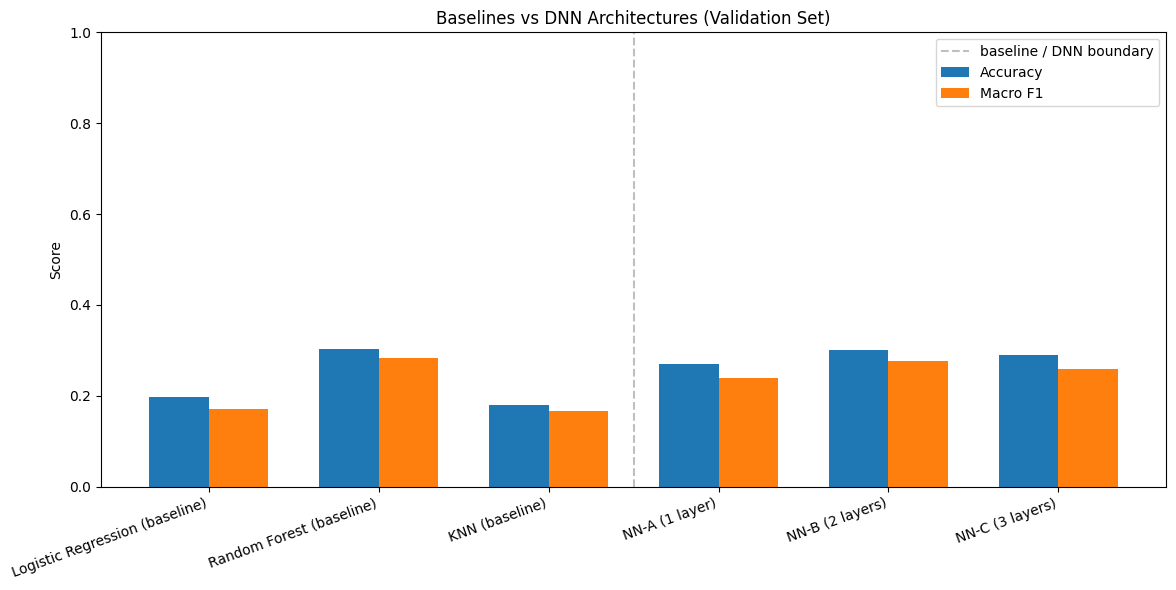

In [10]:
# bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_results))
width = 0.35
bars1 = ax.bar(x - width/2, all_results['Accuracy'], width, label='Accuracy')
bars2 = ax.bar(x + width/2, all_results['Macro F1'], width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Baselines vs DNN Architectures (Validation Set)')
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, label='baseline / DNN boundary')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Training Curves

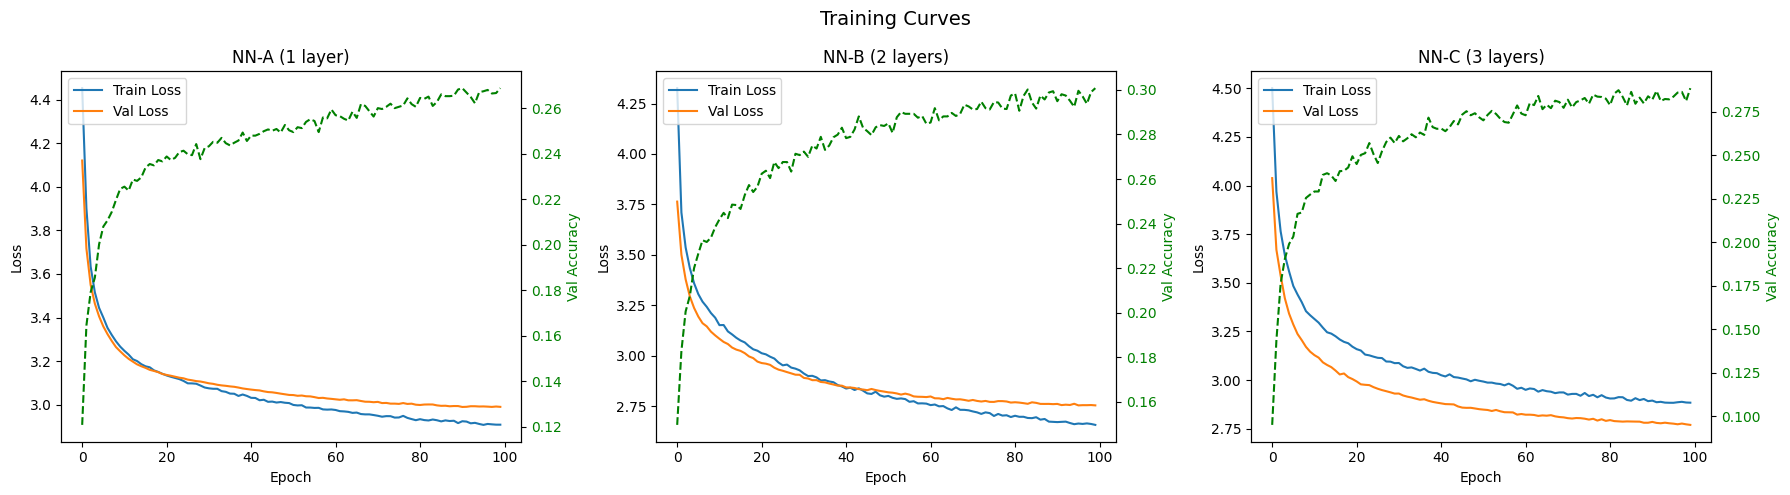

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, result in zip(axes, [nna, nnb, nnc]):
    ax.plot(result['train_losses'], label='Train Loss')
    ax.plot(result['val_losses'],   label='Val Loss')
    ax2 = ax.twinx()
    ax2.plot(result['val_accs'], color='green', linestyle='--', label='Val Acc')
    ax2.set_ylabel('Val Accuracy', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax.set_title(result['name'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper left')

plt.suptitle('Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Best DNN — Detailed Evaluation

In [12]:
# pick best DNN by macro F1
best_dnn = max([nna, nnb, nnc], key=lambda r: r['macro_f1'])
print(f'Best DNN: {best_dnn["name"]}\n')
print(classification_report(y_val, best_dnn['preds'], target_names=le.classes_))

Best DNN: NN-B (2 layers)

                   precision    recall  f1-score   support

         acoustic       0.25      0.33      0.29        45
         afrobeat       0.35      0.33      0.34        45
         alt-rock       0.12      0.04      0.07        45
      alternative       0.15      0.09      0.11        45
          ambient       0.20      0.20      0.20        45
            anime       0.15      0.09      0.11        45
      black-metal       0.49      0.56      0.52        45
        bluegrass       0.43      0.47      0.45        45
            blues       1.00      0.02      0.04        45
           brazil       0.11      0.07      0.08        45
        breakbeat       0.48      0.31      0.38        45
          british       0.10      0.02      0.04        45
         cantopop       0.24      0.22      0.23        45
    chicago-house       0.37      0.49      0.42        45
         children       0.40      0.38      0.39        45
            chill       0.19

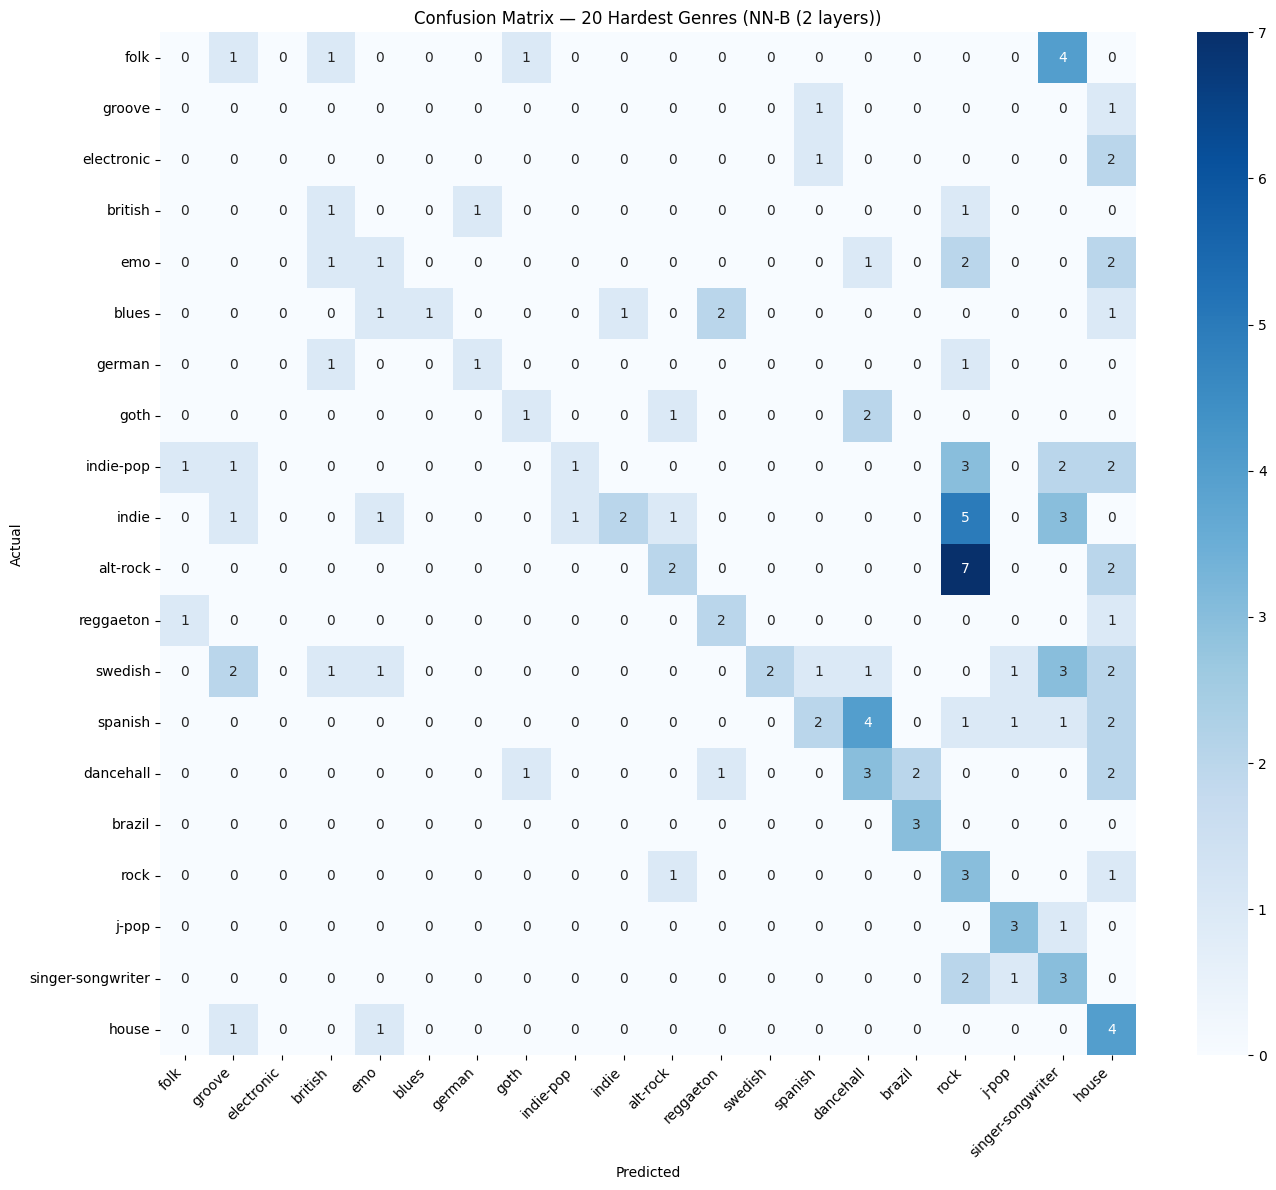

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, best_dnn['preds'])
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_20 = np.argsort(per_class_acc)[:20]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm[np.ix_(worst_20, worst_20)],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_[worst_20],
    yticklabels=le.classes_[worst_20]
)
plt.title(f'Confusion Matrix — 20 Hardest Genres ({best_dnn["name"]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Test Set — Final Score (run once, at the end)
Only evaluate on test set after all tuning is done. Do not use this to make modeling decisions.

In [14]:
best_dnn['model'].eval()
with torch.no_grad():
    test_preds = best_dnn['model'](X_test_t).argmax(1).cpu().numpy()

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds, average='macro')
print(f'{best_dnn["name"]} — TEST SET: Accuracy={test_acc:.4f}, Macro F1={test_f1:.4f}')

NN-B (2 layers) — TEST SET: Accuracy=0.2848, Macro F1=0.2623


---
## Next Steps (Week 5)
- Hyperparameter tuning on best architecture (learning rate, dropout, batch size)
- Feature subset experiments (Experiment 2)
- Cross-dataset evaluation on Source #2 (Experiment 3)

## AI Usage
- Used Claude to help generate DNN architecture and comments.
- Used Claude to structure the comparison against baseline models